/Users/artempopov/anaconda3/lib/python3.10/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


Первичные: 3,757,535 точек, ΣdE = 120901.798 MeV
Вторичные: 22,923 точек, ΣdE = 4547.225 MeV


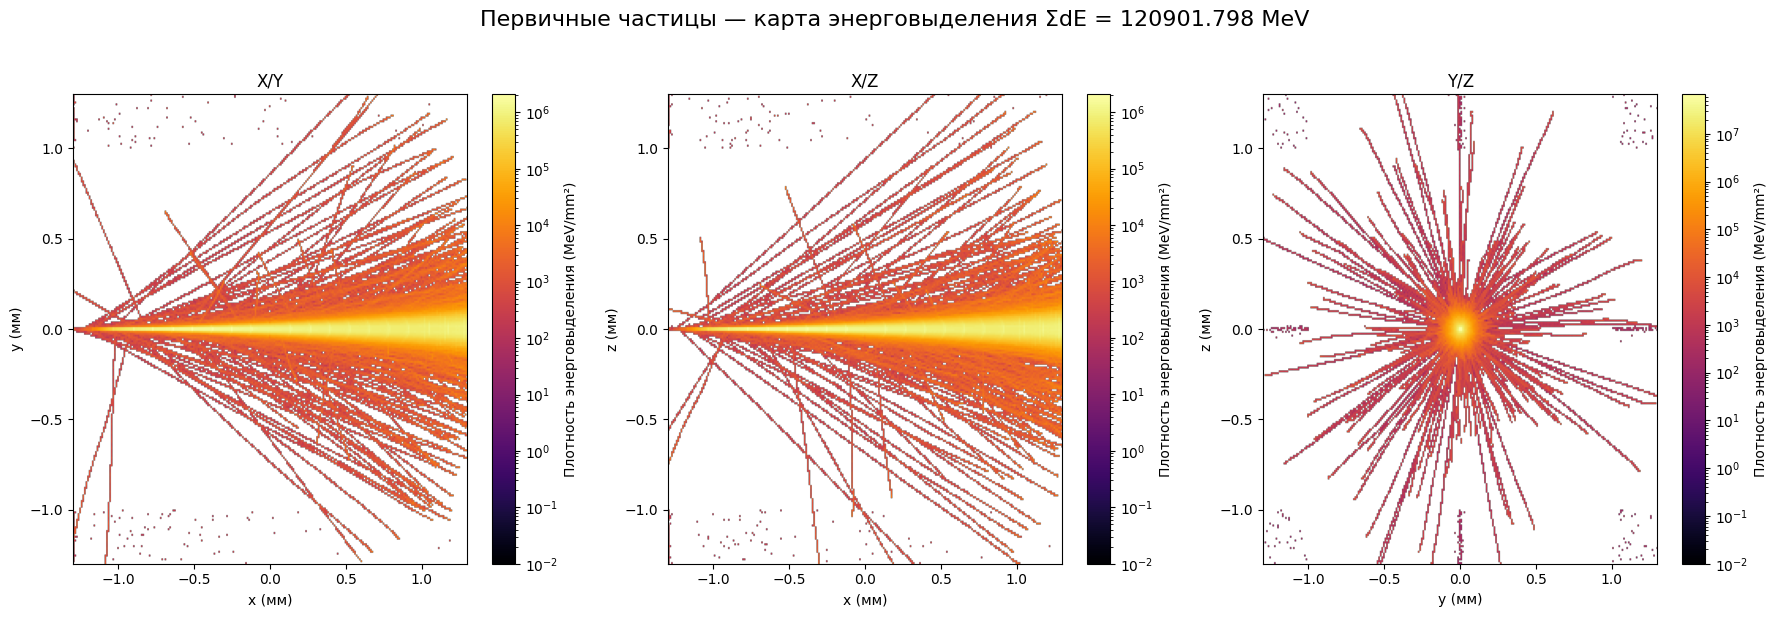

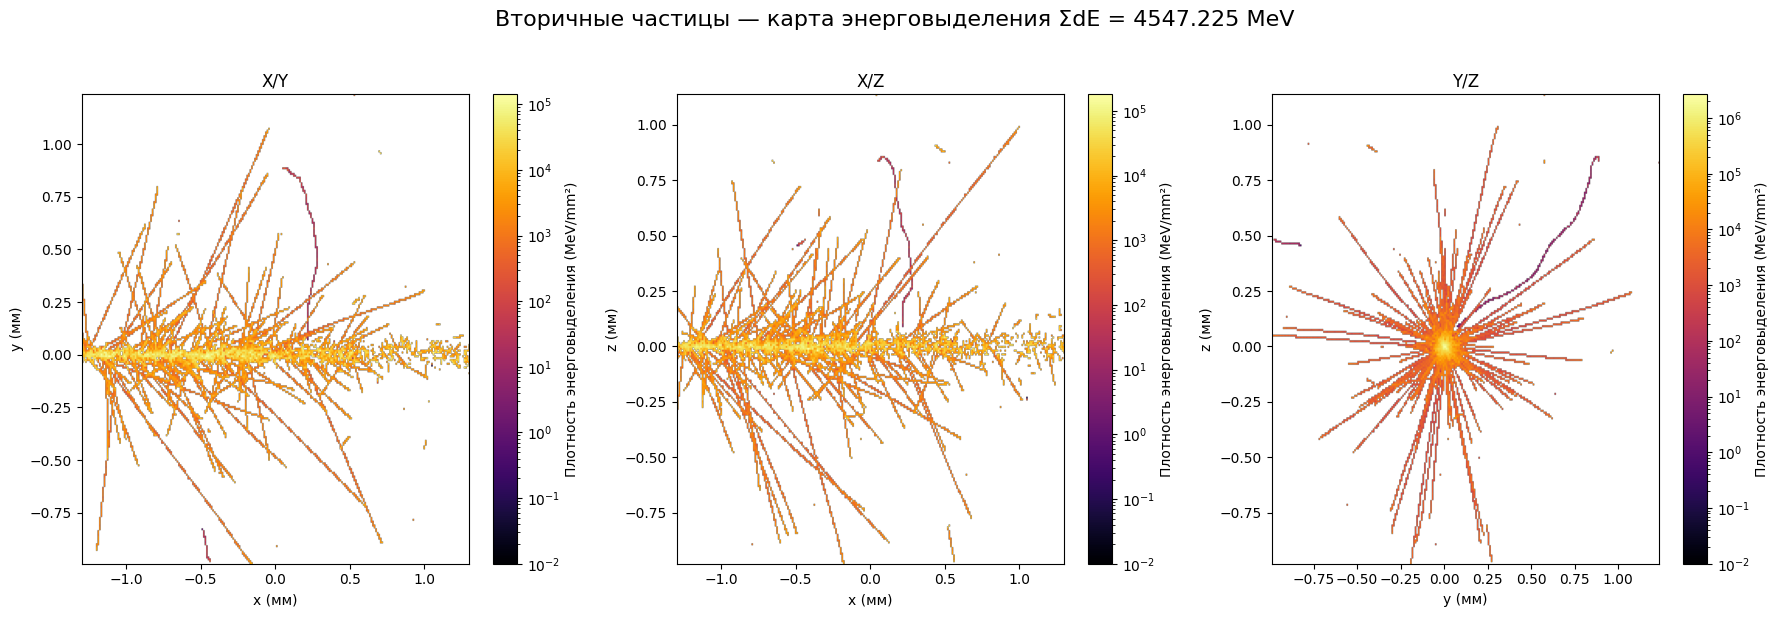

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Загрузка
df_primary = pd.read_csv("Effective traks/primary_de_points_20_MeV.csv")
df_secondary = pd.read_csv("Effective traks/secondary_de_points_20_MeV.csv")

print(f"Первичные: {len(df_primary):,} точек, ΣdE = {df_primary['energy_deposition_mev'].sum():.3f} MeV")
print(f"Вторичные: {len(df_secondary):,} точек, ΣdE = {df_secondary['energy_deposition_mev'].sum():.3f} MeV")

def plot_de_heatmaps(df, title_prefix=""):
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle(
        f"{title_prefix} — карта энерговыделения"
        f" ΣdE = {df['energy_deposition_mev'].sum():.3f} MeV",
        fontsize=16,
        y=1.02,
    )

    projections = [("x_mm", "y_mm", "X/Y"),
                   ("x_mm", "z_mm", "X/Z"),
                   ("y_mm", "z_mm", "Y/Z")]

    bins = 250

    for ax, (colx, coly, proj) in zip(axes, projections):
        x = df[colx]
        y = df[coly]
        weights = df["energy_deposition_mev"]

        # Считаем гистограмму вручную
        H, xedges, yedges = np.histogram2d(
            x, y, bins=bins, weights=weights
        )

        # Размер бина
        dx = (xedges[-1] - xedges[0]) / bins
        dy = (yedges[-1] - yedges[0]) / bins
        area = dx * dy

        # Нормировка на площадь
        H = H / area

        # Рисуем
        im = ax.imshow(
            H.T,
            origin='lower',
            aspect='auto',
            extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
            cmap='inferno',
            norm=plt.cm.colors.LogNorm(vmin=1e-2)
        )

        ax.set_xlabel(colx.replace("_mm", " (мм)"))
        ax.set_ylabel(coly.replace("_mm", " (мм)"))
        ax.set_title(proj)

        fig.colorbar(im, ax=ax, label='Плотность энерговыделения (MeV/mm²)')

    plt.tight_layout()
    plt.show()

# Построение
plot_de_heatmaps(df_primary, "Первичные частицы")
plot_de_heatmaps(df_secondary, "Вторичные частицы")


In [2]:
def build_voxel_grid(df, num_particles=10000, bins=(200, 200, 200)):
    x = df["x_mm"].values
    y = df["y_mm"].values
    z = df["z_mm"].values
    weights = df["energy_deposition_mev"].values / num_particles

    H, edges = np.histogramdd(
        sample=(x, y, z),
        bins=bins,
        weights=weights
    )

    return H, edges

def pad_voxel_grid(H, target_shape):
    H_new = np.zeros(target_shape)

    # текущие размеры
    nx, ny, nz = H.shape
    NX, NY, NZ = target_shape

    # центрирование
    x_start = (NX - nx) // 2
    y_start = (NY - ny) // 2
    z_start = (NZ - nz) // 2

    H_new[
        x_start:x_start+nx,
        y_start:y_start+ny,
        z_start:z_start+nz
    ] = H

    return H_new

def pad_edges(edges, old_shape, new_shape):
    new_edges = []

    for i in range(3):
        old_edges = edges[i]
        dx = old_edges[1] - old_edges[0]

        old_n = old_shape[i]
        new_n = new_shape[i]

        extra = (new_n - old_n) // 2

        start = old_edges[0] - extra * dx
        end = old_edges[-1] + extra * dx

        new_edges.append(np.linspace(start, end, new_n + 1))

    return new_edges

H, edges = build_voxel_grid(df_primary)

print("ΣdE (grid):", H.sum())
print("ΣdE (original):", df_primary["energy_deposition_mev"].sum())

ΣdE (grid): 12.090179764009381
ΣdE (original): 120901.79764009376


In [3]:
def convert_to_density(H, edges):
    # Вычисляем размеры вокселей
    x_edges, y_edges, z_edges = edges
    dx = np.diff(x_edges)  # массив длин по x (должен быть постоянным, если равномерная сетка)
    dy = np.diff(y_edges)
    dz = np.diff(z_edges)

    # Объём одного вокселя (мм³). Если сетка равномерная — можно взять dx[0]*dy[0]*dz[0]
    # Но лучше сделать полный meshgrid для надёжности
    dx_grid, dy_grid, dz_grid = np.meshgrid(dx, dy, dz, indexing='ij')
    voxel_volume = dx_grid * dy_grid * dz_grid   # мм³

    # Теперь правильная объёмная плотность на 1 протон
    epsilon = H / voxel_volume          # MeV / мм³  на один протон

    total_E_from_grid = np.sum(H)                    # должно ≈ df.sum() / 10000
    total_E_from_density = np.sum(epsilon * voxel_volume)
    print(f"total_E_from_grid: {total_E_from_grid} MeV/partcle, total_E_from_density: {total_E_from_density} MeV/partcle")

    return epsilon, voxel_volume

In [4]:
import matplotlib.pyplot as plt
import numpy as np

def plot_projections_from_voxel(H, edges):
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    # edges
    x_edges, y_edges, z_edges = edges

    projections = [
        (H.sum(axis=2), "X/Y", x_edges, y_edges),  # интеграция по z
        (H.sum(axis=1), "X/Z", x_edges, z_edges),  # интеграция по y
        (H.sum(axis=0), "Y/Z", y_edges, z_edges)   # интеграция по x
    ]

    for ax, (proj, title, x_e, y_e) in zip(axes, projections):
        im = ax.imshow(
            proj.T,
            origin='lower',
            extent=[x_e[0], x_e[-1], y_e[0], y_e[-1]],
            aspect='auto',
            cmap='inferno',
            norm=plt.cm.colors.LogNorm(vmin=1e-3)
        )

        ax.set_xlabel(f"{title.split('/')[0]} (мм)")
        ax.set_ylabel(f"{title.split('/')[1]} (мм)")
        ax.set_title(title)

        fig.colorbar(im, ax=ax, label="Energy deposition")

    plt.tight_layout()
    plt.show()

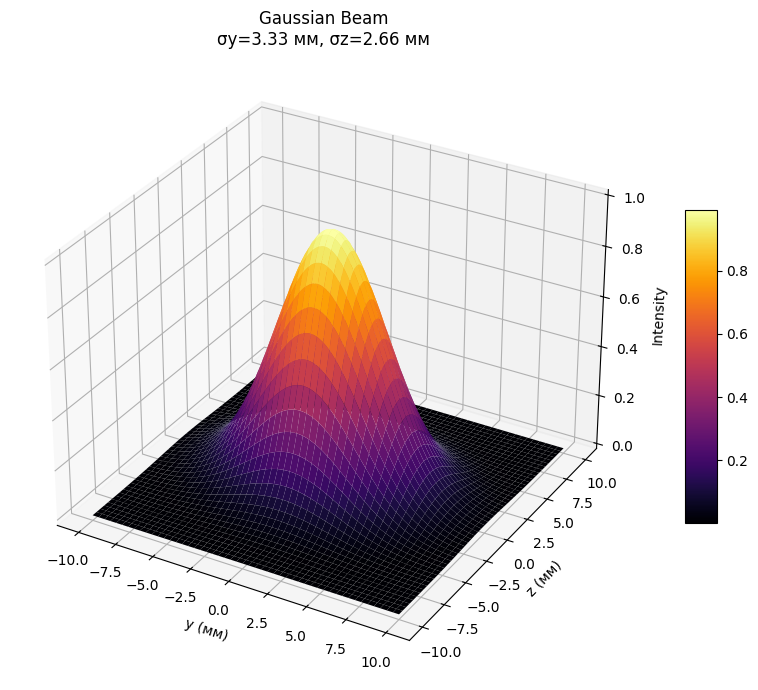

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def plot_gaussian_beam_3d(sigma_y_mm=3.0, sigma_z_mm=3.0, size_mm=20, resolution=200):
    """
    sigma_y_mm, sigma_z_mm — ширина пучка (мм)
    size_mm — размер области визуализации (±size_mm)
    resolution — число точек по каждой оси
    """

    # координатная сетка
    y = np.linspace(-size_mm, size_mm, resolution)
    z = np.linspace(-size_mm, size_mm, resolution)
    Y, Z = np.meshgrid(y, z)

    # Gaussian beam
    I = np.exp(-(Y**2 / (2 * sigma_y_mm**2) + Z**2 / (2 * sigma_z_mm**2)))

    # нормировка (по желанию)
    I /= I.max()

    # 3D plot
    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')

    surf = ax.plot_surface(
        Y, Z, I,
        cmap='inferno',
        linewidth=0,
        antialiased=True
    )

    ax.set_xlabel("y (мм)")
    ax.set_ylabel("z (мм)")
    ax.set_zlabel("Intensity")
    ax.set_title(f"Gaussian Beam\nσy={sigma_y_mm} мм, σz={sigma_z_mm} мм")

    fig.colorbar(surf, shrink=0.5, aspect=10)

    plt.tight_layout()
    plt.show()

plot_gaussian_beam_3d(sigma_y_mm=3.33, sigma_z_mm=2.66, size_mm=10, resolution=800)

In [6]:
from scipy.ndimage import gaussian_filter

def apply_gaussian_beam_physical(H, edges, sigma_y_mm, sigma_z_mm):
    dy = edges[1][1] - edges[1][0]
    dz = edges[2][1] - edges[2][0]

    sigma_y = sigma_y_mm / dy
    sigma_z = sigma_z_mm / dz

    H_blurred = np.zeros_like(H)

    for i in range(H.shape[0]):  # по x
        H_blurred[i] = gaussian_filter(
            H[i],
            sigma=(sigma_y, sigma_z)
        )

    return H_blurred

# Primary

total_E_from_grid: 12.090179764009383 MeV/partcle, total_E_from_density: 12.090179764009383 MeV/partcle


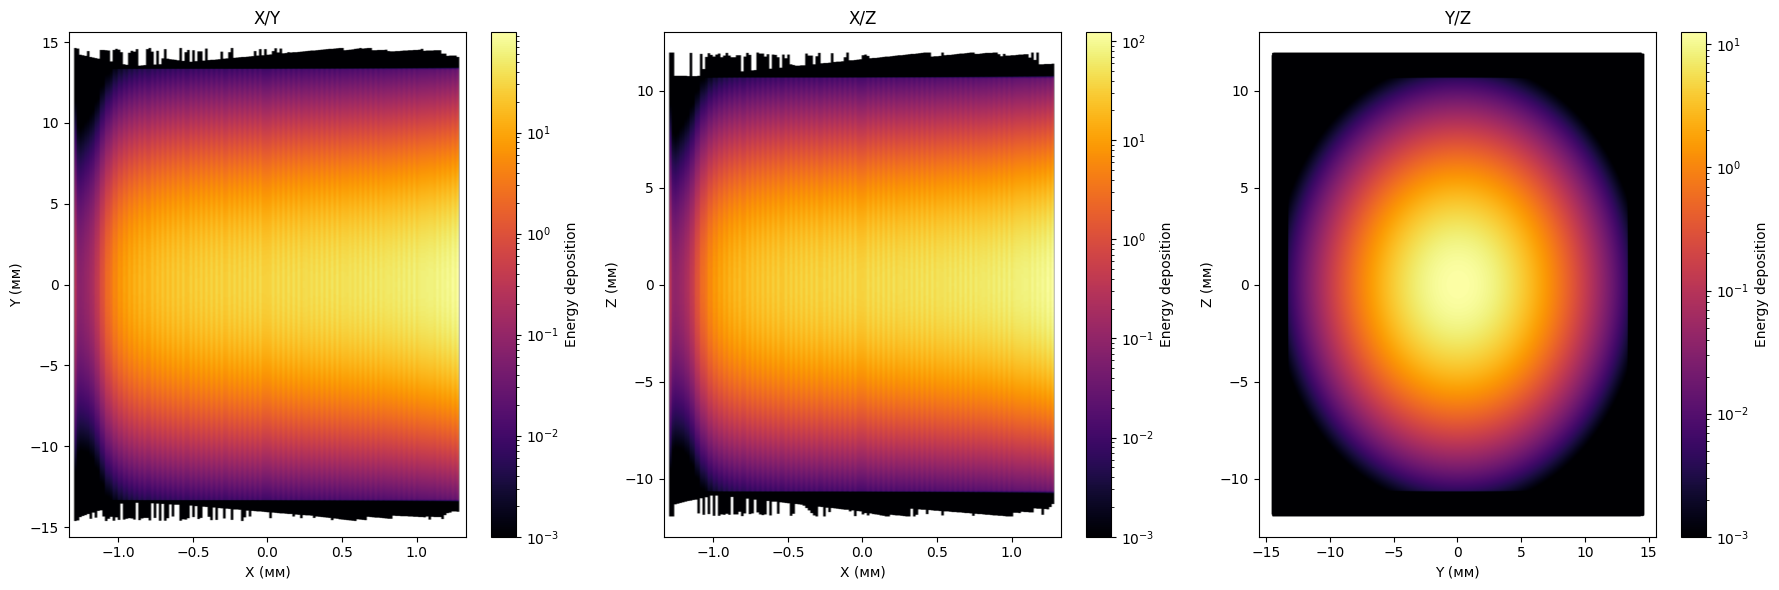

In [9]:
H_primary, edges = build_voxel_grid(df_primary, bins=(150, 150, 150))
epsilon_primary, voxel_volume = convert_to_density(H_primary, edges)

new_shape = (155, 1800, 1500)  # сильно расширили по y,z
epsilon_primary_big = pad_voxel_grid(epsilon_primary, new_shape)
edges_big = pad_edges(edges, epsilon_primary.shape, new_shape)

epsilon_primary_blurred = apply_gaussian_beam_physical(epsilon_primary_big, edges_big, 3.33, 2.66)

plot_projections_from_voxel(epsilon_primary_blurred, edges_big)

Протонов за импульс: 6.242e+13
Максимальная плотность энергии за импульс: 2.548e+00 Дж/мм³
Полная энергия, выделяемая в мишени за один импульс: 120.12178604241355 Дж


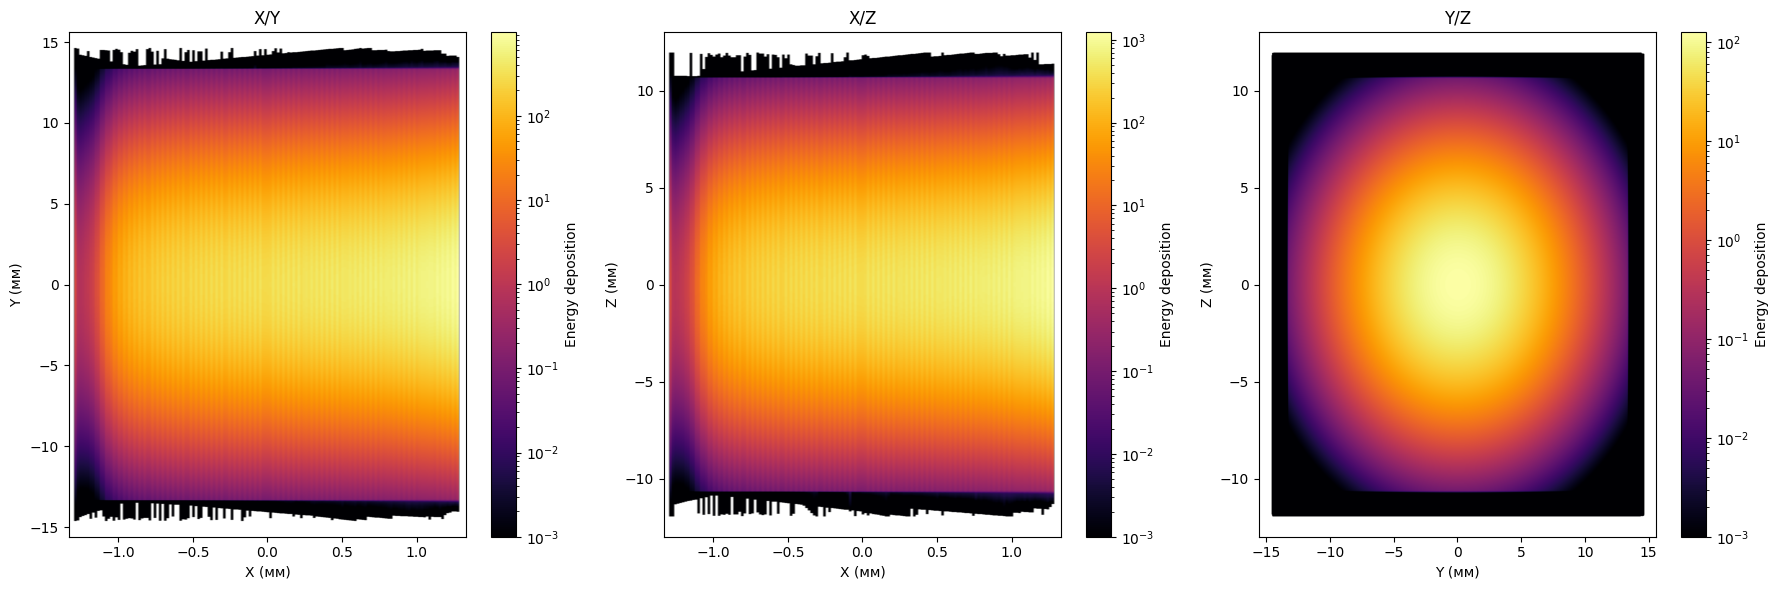

In [10]:
I_peak_mA = 100.0
tau_us = 100.0
f_Hz = 100.0
e = 1.60217662e-19
MeV_to_J = e * 1e6   # Дж в 1 MeV (точно соответствует твоему e)

dx = np.diff(edges_big[0])
dy = np.diff(edges_big[1])
dz = np.diff(edges_big[2])
voxel_volume_mm3 = dx[0]*dy[0]*dz[0]                  # объём одного вокселя в мм³

N_protons_per_pulse = (I_peak_mA * 1e-3 * tau_us * 1e-6) / e
# ~ 6.25e13 протонов за импульс
print(f"Протонов за импульс: {N_protons_per_pulse:.3e}")

epsilon_primary_per_pulse = epsilon_primary_blurred  * N_protons_per_pulse * MeV_to_J
print(f"Максимальная плотность энергии за импульс: {epsilon_primary_per_pulse.max():.3e} Дж/мм³")

total_E_pulse_J = np.sum(epsilon_primary_per_pulse * voxel_volume_mm3)
print(f"Полная энергия, выделяемая в мишени за один импульс: {total_E_pulse_J} Дж")

plot_projections_from_voxel(epsilon_primary_per_pulse, edges_big)

Before: 23215951.697503384
After: 23215951.69750325


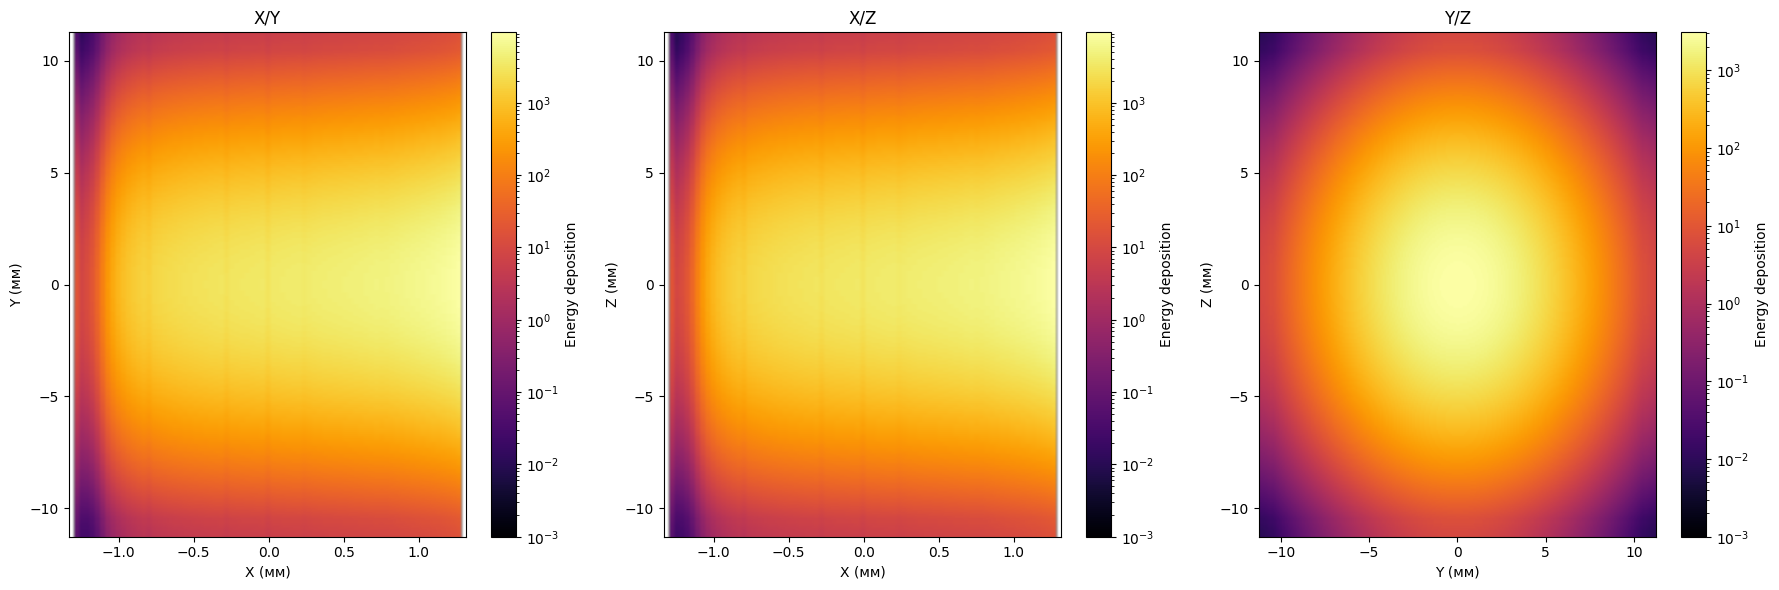

In [10]:
def downsample_voxel_grid(H, factors):
    """
    factors = (fx, fy, fz) — во сколько раз уменьшаем
    """
    fx, fy, fz = factors
    nx, ny, nz = H.shape

    # обрезаем чтобы делилось
    nx_new = (nx // fx) * fx
    ny_new = (ny // fy) * fy
    nz_new = (nz // fz) * fz

    H_cropped = H[:nx_new, :ny_new, :nz_new]

    # reshape + суммирование
    H_down = H_cropped.reshape(
        nx_new // fx, fx,
        ny_new // fy, fy,
        nz_new // fz, fz
    ).sum(axis=(1, 3, 5))

    return H_down

def downsample_edges(edges, factors):
    fx, fy, fz = factors

    edges_x = edges[0][::fx]
    edges_y = edges[1][::fy]
    edges_z = edges[2][::fz]

    return (edges_x, edges_y, edges_z)

epsilon_per_pulse_small = downsample_voxel_grid(epsilon_per_pulse, (2, 5, 5))
edges_small = downsample_edges(edges_big, (2, 5, 5))

print("Before:", epsilon_per_pulse.sum())
print("After:", epsilon_per_pulse_small.sum())

plot_projections_from_voxel(epsilon_per_pulse_small, edges_small)

In [11]:
def downsample_voxel_grid_density(H, factors):
    """
    Даунсемплинг с сохранением размерности плотности (Дж/мм³).
    Использует усреднение, а не суммирование.
    """
    fx, fy, fz = factors
    nx, ny, nz = H.shape
    
    # Обрезаем, чтобы размеры делились нацело
    nx_new = (nx // fx) * fx
    ny_new = (ny // fy) * fy
    nz_new = (nz // fz) * fz
    
    H_cropped = H[:nx_new, :ny_new, :nz_new]
    
    # reshape + mean (усреднение)
    H_down = H_cropped.reshape(
        nx_new // fx, fx,
        ny_new // fy, fy,
        nz_new // fz, fz
    ).mean(axis=(1, 3, 5))          # ← mean вместо sum !
    
    return H_down


def downsample_edges(edges, factors):
    fx, fy, fz = factors
    edges_x = edges[0][::fx]
    edges_y = edges[1][::fy]
    edges_z = edges[2][::fz]
    return (edges_x, edges_y, edges_z)

epsilon_primary_per_pulse_small = downsample_voxel_grid_density(epsilon_primary_per_pulse, (2, 5, 5))
edges_primary_small = downsample_edges(edges_big, (2, 5, 5))

dx_big = np.diff(edges_big[0])
dy_big = np.diff(edges_big[1])
dz_big = np.diff(edges_big[2])
dV_big = dx_big[0]*dy_big[0]*dz_big[0]                  # объём одного вокселя в мм³

dx_small = np.diff(edges_primary_small[0])
dy_small = np.diff(edges_primary_small[1])
dz_small = np.diff(edges_primary_small[2])
dV_small = dx_small[0]*dy_small[0]*dz_small[0]                  # объём одного вокселя в мм³

print("Before  sum:", np.sum(epsilon_primary_per_pulse * dV_big))
print("After   sum:", np.sum(epsilon_primary_per_pulse_small * dV_small))   # будет почти то же
print("Before shape:", epsilon_primary_per_pulse.shape)
print("After  shape:", epsilon_primary_per_pulse_small.shape)

Before  sum: 120.12178604241355
After   sum: 120.12178604241865
Before shape: (155, 1800, 1500)
After  shape: (77, 360, 300)


# Secondary

total_E_from_grid: 0.4547224892731964 MeV/partcle, total_E_from_density: 0.4547224892731964 MeV/partcle


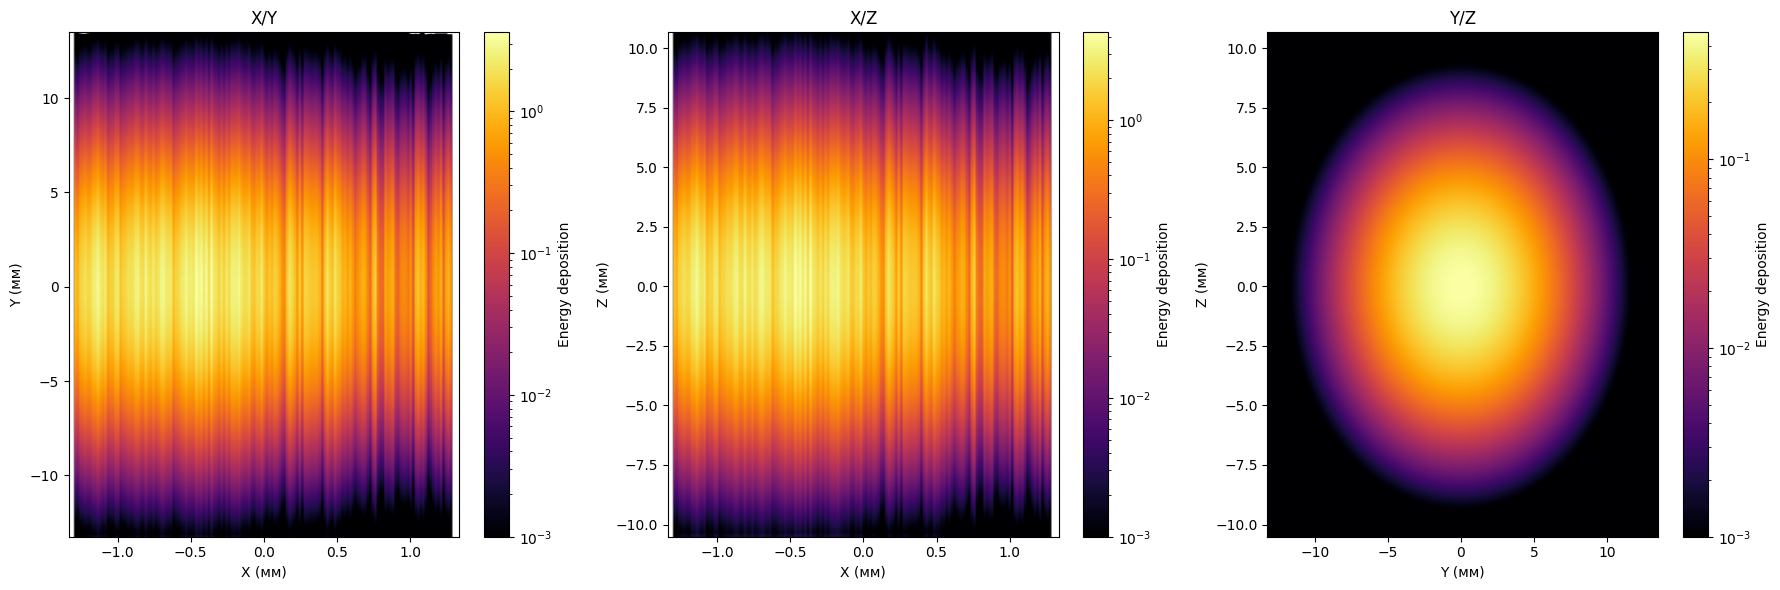

In [12]:
H_secondary, edges = build_voxel_grid(df_secondary, bins=(150, 150, 150))
epsilon_secondary, voxel_volume = convert_to_density(H_secondary, edges)

new_shape = (155, 1800, 1500)  # сильно расширили по y,z
epsilon_secondary_big = pad_voxel_grid(epsilon_secondary, new_shape)
edges_big = pad_edges(edges, epsilon_secondary.shape, new_shape)

epsilon_secondary_blurred = apply_gaussian_beam_physical(epsilon_secondary_big, edges_big, 3.33, 2.66)

plot_projections_from_voxel(epsilon_secondary_blurred, edges_big)

Протонов за импульс: 6.242e+13
Максимальная плотность энергии за импульс: 7.636e-02 Дж/мм³
Полная энергия, выделяемая в мишени за один импульс: 4.517887957940149 Дж


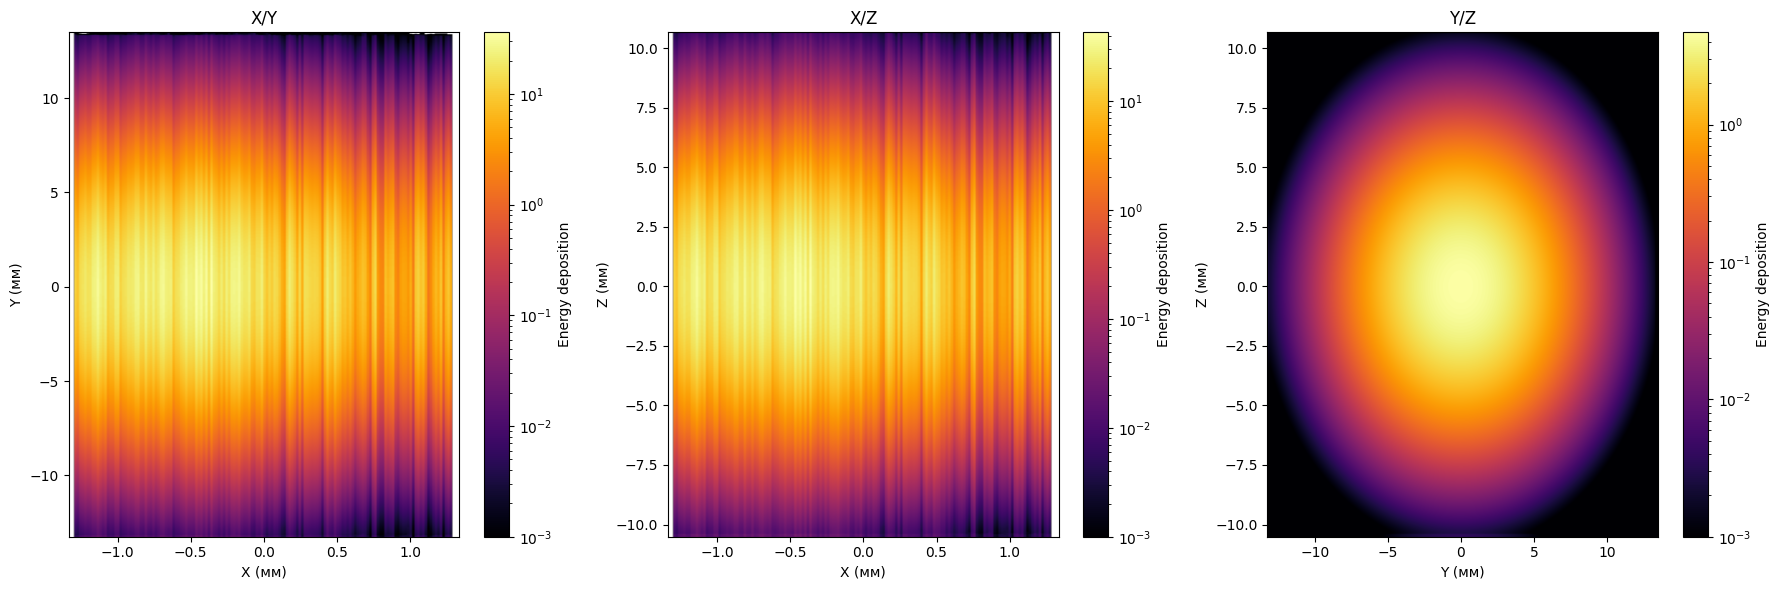

In [13]:
I_peak_mA = 100.0
tau_us = 100.0
f_Hz = 100.0
e = 1.60217662e-19
MeV_to_J = e * 1e6   # Дж в 1 MeV (точно соответствует твоему e)

dx = np.diff(edges_big[0])
dy = np.diff(edges_big[1])
dz = np.diff(edges_big[2])
voxel_volume_mm3 = dx[0]*dy[0]*dz[0]                  # объём одного вокселя в мм³

N_protons_per_pulse = (I_peak_mA * 1e-3 * tau_us * 1e-6) / e
# ~ 6.25e13 протонов за импульс
print(f"Протонов за импульс: {N_protons_per_pulse:.3e}")

epsilon_secondary_per_pulse = epsilon_secondary_blurred  * N_protons_per_pulse * MeV_to_J
print(f"Максимальная плотность энергии за импульс: {epsilon_secondary_per_pulse.max():.3e} Дж/мм³")

total_E_pulse_J = np.sum(epsilon_secondary_per_pulse * voxel_volume_mm3)
print(f"Полная энергия, выделяемая в мишени за один импульс: {total_E_pulse_J} Дж")

plot_projections_from_voxel(epsilon_secondary_per_pulse, edges_big)

In [14]:
epsilon_secondary_per_pulse_small = downsample_voxel_grid_density(epsilon_secondary_per_pulse, (2, 5, 5))
edges_secondary_small = downsample_edges(edges_big, (2, 5, 5))

dx_big = np.diff(edges_big[0])
dy_big = np.diff(edges_big[1])
dz_big = np.diff(edges_big[2])
dV_big = dx_big[0]*dy_big[0]*dz_big[0]                  # объём одного вокселя в мм³

dx_small = np.diff(edges_secondary_small[0])
dy_small = np.diff(edges_secondary_small[1])
dz_small = np.diff(edges_secondary_small[2])
dV_small = dx_small[0]*dy_small[0]*dz_small[0]                  # объём одного вокселя в мм³

print("Before  sum:", np.sum(epsilon_secondary_per_pulse * dV_big))
print("After   sum:", np.sum(epsilon_secondary_per_pulse_small * dV_small))   # будет почти то же
print("Before shape:", epsilon_secondary_per_pulse.shape)
print("After  shape:", epsilon_secondary_per_pulse_small.shape)

Before  sum: 4.517887957940149
After   sum: 4.51788795794011
Before shape: (155, 1800, 1500)
After  shape: (77, 360, 300)


# Summary

In [15]:
import numpy as np
from scipy.interpolate import RegularGridInterpolator

def resample_to_target_grid(
    H_source, edges_source,
    edges_target,
    fill_value=0.0
):
    """
    Переводит 3D поле H_source (плотность!) на новую сетку edges_target
    """

    # координаты центров вокселей (source)
    x_s = 0.5 * (edges_source[0][1:] + edges_source[0][:-1])
    y_s = 0.5 * (edges_source[1][1:] + edges_source[1][:-1])
    z_s = 0.5 * (edges_source[2][1:] + edges_source[2][:-1])

    # интерполятор
    interp = RegularGridInterpolator(
        (x_s, y_s, z_s),
        H_source,
        bounds_error=False,
        fill_value=fill_value
    )

    # координаты target
    x_t = 0.5 * (edges_target[0][1:] + edges_target[0][:-1])
    y_t = 0.5 * (edges_target[1][1:] + edges_target[1][:-1])
    z_t = 0.5 * (edges_target[2][1:] + edges_target[2][:-1])

    X, Y, Z = np.meshgrid(x_t, y_t, z_t, indexing='ij')

    points = np.stack([X.ravel(), Y.ravel(), Z.ravel()], axis=-1)

    # интерполяция
    H_resampled = interp(points).reshape(len(x_t), len(y_t), len(z_t))

    return H_resampled

In [16]:
epsilon_secondary_on_primary = resample_to_target_grid(
    epsilon_secondary_per_pulse_small,
    edges_secondary_small,
    edges_primary_small
)

dx_primary = np.diff(edges_primary_small[0])
dy_primary = np.diff(edges_primary_small[1])
dz_primary = np.diff(edges_primary_small[2])
dV_primary = dx_primary[0]*dy_primary[0]*dz_primary[0]                  # объём одного вокселя в мм³

dx_secondary = np.diff(edges_secondary_small[0])
dy_secondary = np.diff(edges_secondary_small[1])
dz_secondary = np.diff(edges_secondary_small[2])
dV_secondary = dx_secondary[0]*dy_secondary[0]*dz_secondary[0]                  # объём одного вокселя в мм³

# теперь можно сложить
epsilon_summary_per_pulse_small = epsilon_primary_per_pulse_small + epsilon_secondary_on_primary

print("Primary   sum:", np.sum(epsilon_primary_per_pulse_small * dV_primary))
print("Secondary   sum:", np.sum(epsilon_secondary_per_pulse_small * dV_secondary))
print("Summary   sum:", np.sum(epsilon_summary_per_pulse_small * dV_primary))


Primary   sum: 120.12178604241865
Secondary   sum: 4.51788795794011
Summary   sum: 124.6396293992764


In [17]:
import numpy as np
import plotly.graph_objects as go

def save_3d_volume_html(H, edges, filename="beam.html",
                        isomin=None, isomax=None, surface_count=5,
                        colorbar_title="Дж/мм³"):
    """
    Сохраняет 3D isosurface в HTML с подписью цветовой шкалы.
    
    Параметры:
        colorbar_title — текст подписи к colorbar (по умолчанию "Дж/мм³")
    """
    nx, ny, nz = H.shape
    x = np.linspace(edges[0][0], edges[0][-1], nx)
    y = np.linspace(edges[1][0], edges[1][-1], ny)
    z = np.linspace(edges[2][0], edges[2][-1], nz)
    
    X, Y, Z = np.meshgrid(x, y, z, indexing='ij')
    values = H.flatten()

    # Авто-порог, если не задан
    if isomin is None:
        isomin = values.max() * 0.005
    if isomax is None:
        isomax = values.max()

    fig = go.Figure(data=go.Isosurface(
        x=X.flatten(),
        y=Y.flatten(),
        z=Z.flatten(),
        value=values,
        isomin=isomin,
        isomax=isomax,
        surface_count=surface_count,
        # === Настройки colorbar ===
        colorbar=dict(
            title=dict(
                text=colorbar_title,
                side="right",      # или "top"
                font=dict(size=14)
            ),
            thickness=20,          # толщина шкалы
            len=0.8                # длина шкалы относительно графика
        )
    ))

    fig.update_layout(
        title="3D распределение энерговыделения",
        scene=dict(
            xaxis_title='X (мм)',
            yaxis_title='Y (мм)',
            zaxis_title='Z (мм)'
        )
    )

    fig.write_html(filename)
    print(f"Saved to {filename}")

def cut_half_y(H, edges):
    y_edges = edges[1]

    # индекс, где y >= 0
    idx = np.searchsorted(y_edges, 0)

    # обрезаем
    H_half = H[:, idx:, :]
    edges_half = (
        edges[0],
        edges[1][idx:],
        edges[2]
    )

    return H_half, edges_half

In [17]:
epsilon_summary_per_pulse_half, edges_half = cut_half_y(epsilon_summary_per_pulse_small, edges_primary_small)

save_3d_volume_html(
    H=epsilon_summary_per_pulse_half,
    edges=edges_half,
    filename="DARIA_beam_half_summary.html",
    colorbar_title="Энергия за импульс,<br>Дж/мм³",   # можно с переносом строки
    isomin=None,          # или задай вручную
    isomax=None,
    surface_count=6
)

Saved to DARIA_beam_half_summary.html


In [16]:
epsilon_secondary_per_pulse_half, edges_half = cut_half_y(epsilon_secondary_per_pulse_small, edges_small)

save_3d_volume_html(
    H=epsilon_secondary_per_pulse_half,
    edges=edges_half,
    filename="DARIA_beam_half_secondary.html",
    colorbar_title="Энергия за импульс,<br>Дж/мм³",   # можно с переносом строки
    isomin=None,          # или задай вручную
    isomax=None,
    surface_count=6
)

Saved to DARIA_beam_half_secondary.html


In [18]:
epsilon_primary_per_pulse_half, edges_half = cut_half_y(epsilon_primary_per_pulse_small, edges_primary_small)

save_3d_volume_html(
    H=epsilon_primary_per_pulse_half,
    edges=edges_half,
    filename="DARIA_beam_half_primary.html",
    colorbar_title="Энергия за импульс,<br>Дж/мм³",   # можно с переносом строки
    isomin=None,          # или задай вручную
    isomax=None,
    surface_count=6
)

epsilon_secondary_per_pulse_half, edges_half = cut_half_y(epsilon_secondary_per_pulse_small, edges_secondary_small)

save_3d_volume_html(
    H=epsilon_secondary_per_pulse_half,
    edges=edges_half,
    filename="DARIA_beam_half_secondary.html",
    colorbar_title="Энергия за импульс,<br>Дж/мм³",   # можно с переносом строки
    isomin=None,          # или задай вручную
    isomax=None,
    surface_count=6
)

epsilon_summary_per_pulse_half, edges_half = cut_half_y(epsilon_summary_per_pulse_small, edges_primary_small)

save_3d_volume_html(
    H=epsilon_summary_per_pulse_half,
    edges=edges_half,
    filename="DARIA_beam_half_summary.html",
    colorbar_title="Энергия за импульс,<br>Дж/мм³",   # можно с переносом строки
    isomin=None,          # или задай вручную
    isomax=None,
    surface_count=6
)

Saved to DARIA_beam_half_primary.html
Saved to DARIA_beam_half_secondary.html
Saved to DARIA_beam_half_summary.html


In [14]:
import numpy as np
from tqdm import tqdm

def _get_voxel_volume(edges):
    """Вычисляет объём одного вокселя в мм³ (предполагаем равномерную сетку)"""
    dx = np.diff(edges[0])[0]
    dy = np.diff(edges[1])[0]
    dz = np.diff(edges[2])[0]
    return dx * dy * dz


def save_heat_source_for_simulation(
    H: np.ndarray,
    edges: tuple,
    filename_base: str = "heat_source",
    frequency_Hz: float = 100.0,
    mode: str = "average_power_W_per_m3",
    comsol_comment: str = "Тепловыделение в мишени DARIA"
):
    """
    Сохраняет распределение для COMSOL и ANSYS.

    Параметры:
        H              — 3D массив в Дж/мм³ (энергия за один импульс)
        edges          — (edges_x, edges_y, edges_z)
        filename_base  — базовое имя файлов
        frequency_Hz   — частота повторения импульсов
        mode           — в какие единицы сохранять:
                          "energy_per_pulse_J_per_mm3"
                          "average_power_W_per_mm3"
                          "average_power_W_per_m3"   ← рекомендуется для COMSOL/ANSYS
    """
    dV_mm3 = _get_voxel_volume(edges)
    total_energy_J = np.sum(H * dV_mm3)
    print(f"Полная энергия за импульс (проверка): {total_energy_J:.6f} Дж")
    print(f"Размер сетки: {H.shape}, объём вокселя: {dV_mm3:.6f} мм³")

    # === Конверсия единиц ===
    if mode == "energy_per_pulse_J_per_mm3":
        data = H.copy()
        unit = "J/mm³ (за импульс)"
        comsol_unit = "J/mm^3"
        ansys_header = "x_mm,y_mm,z_mm,energy_J_per_mm3"

    elif mode == "average_power_W_per_mm3":
        data = H * frequency_Hz
        unit = "W/mm³ (средняя мощность)"
        comsol_unit = "W/mm^3"
        ansys_header = "x_mm,y_mm,z_mm,power_W_per_mm3"

    elif mode == "average_power_W_per_m3":
        data = H * frequency_Hz * 1e9          # 1 мм³ = 10^{-9} м³
        unit = "W/m³ (средняя мощность, СИ)"
        comsol_unit = "W/m^3"
        ansys_header = "x_m,y_m,z_m,power_W_per_m3"
    else:
        raise ValueError("Неверный mode")

    print(f"Сохраняем в режиме: {unit}")

    # ====================== COMSOL Grid format ======================
    comsol_file = f"{filename_base}_comsol_grid.txt"
    ex, ey, ez = edges

    with open(comsol_file, "w", encoding="utf-8") as f:
        f.write(f"% {comsol_comment} — {comsol_unit}\n")
        f.write("% Grid\n")
        f.write(" ".join(f"{x:.10e}" for x in ex) + "\n")
        f.write(" ".join(f"{y:.10e}" for y in ey) + "\n")
        f.write(" ".join(f"{z:.10e}" for z in ez) + "\n")
        f.write("% Data\n")

        # COMSOL: x — самый быстрый индекс
        for k in range(len(ez) - 1):
            for j in range(len(ey) - 1):
                row = [f"{data[i, j, k]:.10e}" for i in range(len(ex) - 1)]
                f.write(" ".join(row) + "\n")

    print(f"✓ COMSOL Grid сохранён → {comsol_file}")

    # ====================== ANSYS External Data ======================
    ansys_file = f"{filename_base}_ansys.csv"

    # Центры вокселей
    cx = (ex[:-1] + ex[1:]) / 2
    cy = (ey[:-1] + ey[1:]) / 2
    cz = (ez[:-1] + ez[1:]) / 2

    if mode == "average_power_W_per_m3":
        # переводим координаты в метры
        cx, cy, cz = cx * 1e-3, cy * 1e-3, cz * 1e-3

    X, Y, Z = np.meshgrid(cx, cy, cz, indexing='ij')
    values_flat = data.flatten()

    # Записываем CSV
    with open(ansys_file, "w", encoding="utf-8") as f:
        f.write(ansys_header + "\n")
        for i in tqdm(range(len(values_flat))):
            f.write(f"{X.flatten()[i]:.10e},{Y.flatten()[i]:.10e},{Z.flatten()[i]:.10e},{values_flat[i]:.10e}\n")

    print(f"✓ ANSYS CSV сохранён → {ansys_file}")
    print(f"Готово! Можно импортировать в COMSOL/ANSYS.\n")

In [15]:
# Сохраняем в СИ-единицах (рекомендуется)
save_heat_source_for_simulation(
    H=epsilon_primary_per_pulse_small,           # Дж/мм³ за импульс
    edges=edges_primary_small,
    filename_base="daria_beryllium_heat_primary",
    frequency_Hz=100.0,
    mode="average_power_W_per_m3",       # ← самый удобный режим
    comsol_comment="Тепловыделение в Be-мишени КИН DARIA 20 МэВ 2.6 мм"
)

Полная энергия за импульс (проверка): 120.121786 Дж
Размер сетки: (77, 300, 300), объём вокселя: 0.000259 мм³
Сохраняем в режиме: W/m³ (средняя мощность, СИ)
✓ COMSOL Grid сохранён → daria_beryllium_heat_primary_comsol_grid.txt


  0%|          | 6321/6930000 [01:31<27:48:57, 69.14it/s]


KeyboardInterrupt: 

In [ ]:
# Сохраняем в СИ-единицах (рекомендуется)
save_heat_source_for_simulation(
    H=epsilon_primary_per_pulse_small,           # Дж/мм³ за импульс
    edges=edges_small,
    filename_base="daria_beryllium_heat_primary",
    frequency_Hz=100.0,
    mode="average_power_W_per_m3",       # ← самый удобный режим
    comsol_comment="Тепловыделение в Be-мишени КИН DARIA 20 МэВ 2.6 мм"
)

save_heat_source_for_simulation(
    H=epsilon_secondary_per_pulse_small,           # Дж/мм³ за импульс
    edges=edges_small,
    filename_base="daria_beryllium_heat_secondary",
    frequency_Hz=100.0,
    mode="average_power_W_per_m3",       # ← самый удобный режим
    comsol_comment="Тепловыделение в Be-мишени КИН DARIA 20 МэВ 2.6 мм"
)

save_heat_source_for_simulation(
    H=epsilon_summary_per_pulse_small,           # Дж/мм³ за импульс
    edges=edges_small,
    filename_base="daria_beryllium_heat_summary",
    frequency_Hz=100.0,
    mode="average_power_W_per_m3",       # ← самый удобный режим
    comsol_comment="Тепловыделение в Be-мишени КИН DARIA 20 МэВ 2.6 мм"
)

In [17]:
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

def save_3d_volume_html_with_slices(H, edges, filename="beam_with_slices.html",
                                    isomin=None, isomax=None, surface_count=5,
                                    colorbar_title="Дж/мм³"):
    """
    Сохраняет интерактивный 3D объём + три слайдера для просмотра сечений по X, Y, Z.
    
    Параметры:
        H          — 3D массив энерговыделения (nx, ny, nz)
        edges      — список из трёх массивов границ [edges_x, edges_y, edges_z]
        filename   — имя сохраняемого HTML-файла
        colorbar_title — название цветовой шкалы
    """
    nx, ny, nz = H.shape
    
    # Координатные оси
    x = np.linspace(edges[0][0], edges[0][-1], nx)
    y = np.linspace(edges[1][0], edges[1][-1], ny)
    z = np.linspace(edges[2][0], edges[2][-1], nz)
    
    X, Y, Z = np.meshgrid(x, y, z, indexing='ij')
    
    # Авто-пороги
    if isomin is None:
        isomin = H.max() * 0.05
    if isomax is None:
        isomax = H.max()

    # ====================== Создаём фигуру ======================
    fig = go.Figure()

    # 1. Основная изоповерхность (можно скрыть/показать)
    fig.add_trace(go.Isosurface(
        x=X.flatten(),
        y=Y.flatten(),
        z=Z.flatten(),
        value=H.flatten(),
        isomin=isomin,
        isomax=isomax,
        surface_count=surface_count,
        colorscale='Viridis',
        colorbar=dict(
            title=dict(text=colorbar_title, side="right", font=dict(size=14)),
            thickness=20,
            len=0.8
        ),
        name="Isosurface",
        showscale=True,
        opacity=0.7
    ))

    # 2. Три плоскости-среза (volume slices)
    # Срез по X (вертикальная плоскость YZ)
    fig.add_trace(go.Volume(
        x=X.flatten(), y=Y.flatten(), z=Z.flatten(),
        value=H.flatten(),
        slices_x=dict(show=True, locations=[x[nx//2]]),
        opacity=0.6,
        surface_count=1,
        colorscale='Viridis',
        showscale=False,
        name="Slice X"
    ))

    # Срез по Y (вертикальная плоскость XZ)
    fig.add_trace(go.Volume(
        x=X.flatten(), y=Y.flatten(), z=Z.flatten(),
        value=H.flatten(),
        slices_y=dict(show=True, locations=[y[ny//2]]),
        opacity=0.6,
        surface_count=1,
        colorscale='Viridis',
        showscale=False,
        name="Slice Y"
    ))

    # Срез по Z (горизонтальная плоскость XY)
    fig.add_trace(go.Volume(
        x=X.flatten(), y=Y.flatten(), z=Z.flatten(),
        value=H.flatten(),
        slices_z=dict(show=True, locations=[z[nz//2]]),
        opacity=0.6,
        surface_count=1,
        colorscale='Viridis',
        showscale=False,
        name="Slice Z"
    ))

    # ====================== Слайдеры ======================
    steps_x = []
    for val in x:
        step = dict(
            method="update",
            args=[{"slices_x.locations": [[val]]}],
            label=f"{val:.2f}"
        )
        steps_x.append(step)

    steps_y = []
    for val in y:
        step = dict(
            method="update",
            args=[{"slices_y.locations": [[val]]}],
            label=f"{val:.2f}"
        )
        steps_y.append(step)

    steps_z = []
    for val in z:
        step = dict(
            method="update",
            args=[{"slices_z.locations": [[val]]}],
            label=f"{val:.2f}"
        )
        steps_z.append(step)

    # Добавляем слайдеры в layout
    fig.update_layout(
        title="3D распределение энерговыделения с интерактивными сечениями",
        scene=dict(
            xaxis_title='X (мм)',
            yaxis_title='Y (мм)',
            zaxis_title='Z (мм)',
            aspectmode='data'   # сохраняет реальные пропорции
        ),
        sliders=[
            # Слайдер по X
            dict(
                active=nx//2,
                currentvalue={"prefix": "X = ", "suffix": " мм"},
                pad={"t": 50},
                steps=steps_x,
                x=0.0, y=0.02, len=0.3
            ),
            # Слайдер по Y
            dict(
                active=ny//2,
                currentvalue={"prefix": "Y = ", "suffix": " мм"},
                pad={"t": 100},
                steps=steps_y,
                x=0.35, y=0.02, len=0.3
            ),
            # Слайдер по Z
            dict(
                active=nz//2,
                currentvalue={"prefix": "Z = ", "suffix": " мм"},
                pad={"t": 150},
                steps=steps_z,
                x=0.70, y=0.02, len=0.3
            )
        ],
        height=800
    )

    # Опционально: кнопки для скрытия/показа изоповерхности
    fig.update_traces(visible=True, selector=dict(name="Isosurface"))
    
    fig.write_html(filename, include_plotlyjs='cdn', full_html=True)
    print(f"Файл сохранён: {filename}")
    print("Слайдеры добавлены: X, Y, Z. Можно двигать мышкой.")

def cut_half_y(H, edges):
    y_edges = edges[1]

    # индекс, где y >= 0
    idx = np.searchsorted(y_edges, 0)

    # обрезаем
    H_half = H[:, idx:, :]
    edges_half = (
        edges[0],
        edges[1][idx:],
        edges[2]
    )

    return H_half, edges_half

In [18]:
epsilon_per_pulse_half, edges_half = cut_half_y(epsilon_per_pulse_small, edges_small)

save_3d_volume_html_with_slices(epsilon_per_pulse_half, edges_half, 
                                filename="DARIA_beam_half_sliders.html",
                                surface_count=6,
                                colorbar_title="Энергия, Дж/мм³")

Файл сохранён: DARIA_beam_half_sliders.html
Слайдеры добавлены: X, Y, Z. Можно двигать мышкой.
